In [97]:
import pandas as pd
import numpy as np
import pickle

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np



In [98]:
# Load datasets
X_train_selected = pd.read_parquet("../Data_cleaning/X_train_selected.parquet")
X_test_selected = pd.read_parquet("../Data_cleaning/X_test_selected.parquet")

#def add_web_flow_features(df):
#    eps = 1e-6  # prevent division by zero

    # 1️⃣ Request–response asymmetry (Web attacks are client-heavy)
#    df["web_req_resp_ratio"] = (
#        df["fwd_packet_length_max"] + eps
#    ) / (
#         df["bwd_packet_length_max"] + eps
#     )

#     # 2️⃣ Short-lived flow indicator (XSS, SQLi)
#     df["web_short_flow"] = (df["flow_duration"] < 1e5).astype(int)

#     # 3️⃣ Small payload dominance
#     df["web_small_payload"] = (df["fwd_packet_length_mean"] < 200).astype(int)

#     # 4️⃣ Burst behavior (optional but useful)
#     df["web_burst_rate"] = (
#         df["flow_packets/s"] / (df["flow_duration"] + eps)
#     )

#     return df

#X_train_selected = add_web_flow_features(X_train_selected)
#X_test_selected  = add_web_flow_features(X_test_selected)


y_train = pd.read_parquet("../Data_cleaning/y_train.parquet")["label"]
y_test = pd.read_parquet("../Data_cleaning/y_test.parquet")["label"]

# Load artifacts
with open("../Data_cleaning/labelencoder.pkl", "rb") as f:
    le = pickle.load(f)

# ==============================
# FILTER RARE ATTACK CLASS (SUPERVISED ONLY)
# ==============================

X_train_selected = X_train_selected.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test_selected = X_test_selected.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Identify label index for 'Rare'
rare_label = list(le.classes_).index("Rare")
print("Rare label index:", rare_label)

train_mask = y_train != rare_label
test_mask = y_test != rare_label
#Filter train data
X_train_selected = X_train_selected.loc[train_mask].reset_index(drop=True)
y_train = y_train.loc[train_mask].reset_index(drop=True)

# Filter test data
X_test_selected = X_test_selected.loc[test_mask].reset_index(drop=True)
y_test = y_test.loc[test_mask].reset_index(drop=True)

from sklearn.preprocessing import LabelEncoder
le_xgb = LabelEncoder()
y_train_xgb = le_xgb.fit_transform(y_train)
y_test_xgb = le_xgb.transform(y_test)


print("After filtering Rare:")
print("Train label distribution:\n", y_train.value_counts())
print("Test label distribution:\n", y_test.value_counts())


print("Data loaded successfully")
print("Train shape:", X_train_selected.shape)
print("Test shape:", X_test_selected.shape)




Rare label index: 4
After filtering Rare:
Train label distribution:
 label
2    257407
0    198402
1      8496
5      1565
3      1150
6       538
Name: count, dtype: int64
Test label distribution:
 label
2    64352
0    49601
1     2124
5      391
3      287
6      135
Name: count, dtype: int64
Data loaded successfully
Train shape: (467558, 48)
Test shape: (116890, 48)


In [99]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(
    solver="saga",
    multi_class="multinomial",
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_selected, y_train)

y_pred_lr = lr.predict(X_test_selected)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))


c:\Users\siddh\miniconda3\envs\ds_2\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.86      0.43      0.57     49601
           1       0.50      0.64      0.56      2124
           2       0.72      0.86      0.79     64352
           3       0.00      0.00      0.00       287
           5       0.06      0.40      0.11       391
           6       0.02      0.91      0.03       135

    accuracy                           0.67    116890
   macro avg       0.36      0.54      0.34    116890
weighted avg       0.77      0.67      0.69    116890



c:\Users\siddh\miniconda3\envs\ds_2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [101]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_selected, y_train)

y_pred_rf = rf.predict(X_test_selected)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     49601
           1       0.99      0.91      0.95      2124
           2       1.00      1.00      1.00     64352
           3       0.55      0.99      0.71       287
           5       0.95      0.99      0.97       391
           6       0.39      0.87      0.54       135

    accuracy                           0.99    116890
   macro avg       0.81      0.96      0.86    116890
weighted avg       1.00      0.99      0.99    116890



In [102]:
from xgboost import XGBClassifier

#siddharth_changes_s
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import classification_report
#siddharth_change_e

# ------------------------------
# CLASS WEIGHT BOOSTING
# ------------------------------
classes = np.unique(y_train_xgb)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_xgb
)
class_weight_dict = dict(zip(classes, class_weights))

print("classes:",classes)
print("class_weights",class_weights)

sample_weights = np.array([class_weight_dict[y] for y in y_train_xgb])

# ------------------------------
# XGBOOST MODEL (WEB-FRIENDLY)
# ------------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,              # reduced for minority classes (Web)
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax", # better class decision
    num_class=len(le_xgb.classes_),
    eval_metric="merror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# Train with class weights
xgb.fit(
    X_train_selected,
    y_train_xgb,
    sample_weight=sample_weights
)



y_pred_xgb = xgb.predict(X_test_selected)

print("XGBoost Results(Rare removed)")
class_names_no_rare = [
    cls for cls in le.classes_ if cls != "Rare"
]


print(classification_report(y_test_xgb, 
                            y_pred_xgb,
                            target_names= class_names_no_rare
))

#printing false positive rate(FPR)


cm = confusion_matrix(y_test_xgb, y_pred_xgb)
class_names = le_xgb.classes_

#computing the FPR per class
fpr_per_class = {}

for i, cls in enumerate(class_names):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])

    fpr = FP / (FP + TN)
    fpr_per_class[cls] = fpr

#printing the FPR per class
print("False Positive Rate per class:")
for cls, fpr in fpr_per_class.items():
    print(f"{str(cls):12s}: {fpr:.4f}")


overall_fpr = np.mean(list(fpr_per_class.values()))
print(f"\nOverall False Positive Rate (macro): {overall_fpr:.4f}")





classes: [0 1 2 3 4 5]
class_weights [  0.3927699    9.17212021   0.30273587  67.76202899  49.79318424
 144.84448575]
XGBoost Results(Rare removed)
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     49601
  BruteForce       0.98      0.95      0.96      2124
         DoS       1.00      1.00      1.00     64352
     Malware       0.90      0.98      0.94       287
        Scan       0.96      0.99      0.97       391
         Web       0.45      0.67      0.54       135

    accuracy                           1.00    116890
   macro avg       0.88      0.93      0.90    116890
weighted avg       1.00      1.00      1.00    116890

False Positive Rate per class:
0           : 0.0003
1           : 0.0004
2           : 0.0005
3           : 0.0003
5           : 0.0001
6           : 0.0009

Overall False Positive Rate (macro): 0.0004


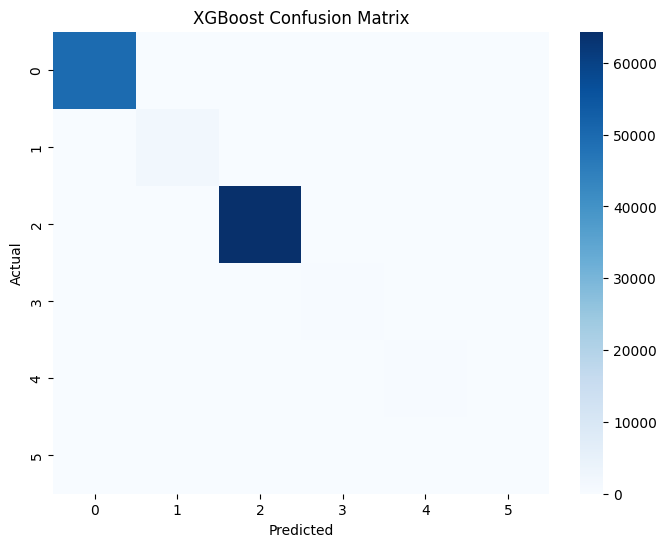

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt
#from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test_xgb, y_pred_xgb, "XGBoost Confusion Matrix")


In [104]:
from sklearn.metrics import f1_score, classification_report

# Collect predictions
predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

# Evaluate F1-score (macro-average for multi-class)
f1_scores = {}
for name, y_pred in predictions.items():
    if name == "XGBoost":
        # XGBoost uses encoded labels
        f1 = f1_score(y_test_xgb, y_pred, average="macro")
        class_names_no_rare = [cls for cls in le.classes_ if cls != "Rare"]

        print(classification_report(
            y_test_xgb,
            y_pred,
            target_names=class_names_no_rare
        ))
    else:
        # Other models use original labels
        f1 = f1_score(y_test, y_pred, average="macro")
        print(classification_report(y_test, y_pred))

    f1_scores[name] = f1
    # f1 = f1_score(y_test, y_pred, average="macro")
    # f1_scores[name] = f1
    # print(f"--- {name} ---")
    # print(classification_report(y_test, y_pred))

# Select best model
best_model_name = max(f1_scores, key=f1_scores.get)
print(f"\n Best model based on F1-score: {best_model_name}")

# Map model name to trained object
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}
best_model = models[best_model_name]

# Save the final model
import pickle
with open("final_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"Final model saved: {best_model_name}")



              precision    recall  f1-score   support

           0       0.86      0.43      0.57     49601
           1       0.50      0.64      0.56      2124
           2       0.72      0.86      0.79     64352
           3       0.00      0.00      0.00       287
           5       0.06      0.40      0.11       391
           6       0.02      0.91      0.03       135

    accuracy                           0.67    116890
   macro avg       0.36      0.54      0.34    116890
weighted avg       0.77      0.67      0.69    116890

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     49601
           1       0.99      0.91      0.95      2124
           2       1.00      1.00      1.00     64352
           3       0.55      0.99      0.71       287
           5       0.95      0.99      0.97       391
           6       0.39      0.87      0.54       135

    accuracy                           0.99    116890
   macro avg       0.81